# Knowledge Based Position Prediction

We use knowledge graph embeddings to predict the position of a player in league of legends based on the top 5 players

### Presets

In [1]:
import pandas as pd
import networkx as nx
import tqdm

from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory
from pykeen.predict import predict_target

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from util.db.graph import Neo4JConnector
from util.graph_tools import visualize_graph
from util.graph_tools import create_graph_from_query

import matplotlib.pyplot as plt

In [2]:
random_state = 4201312
node_color = {"Position": 0, "Champion": 1, "Player": 2}
position_color = {'BOT': "#ee4035", 'SUP': "#f37736", 'JGL': "#fdf498", 'MID': "#7bc043", 'TOP': "#0392cf"}

neo4j = Neo4JConnector.create_from_config("../config.ini")

## Build Graph

From the Neo4J database we select all players (with more than 10 games and a known position) with their preferred champions (<= 5).

We visualize the subgraph for 5 players.  

In [3]:
result = neo4j.exec("""CALL {
        MATCH (p:Player)-[pi:PLAYS_IN]->(pim:PlayerInMatch)
        WITH p, COUNT(pim.matchID) AS matchesPlayed 
        WHERE matchesPlayed > 10
        RETURN p
    }
    MATCH (p)-[pc:PLAYS_CHAMP]->(c:Champion), (p)-[hp:HAS_POSITION]->(pos:Position)
    RETURN * LIMIT 1000""")

g = nx.DiGraph()
create_graph_from_query(graph=g, result=result)
str(g)

'DiGraph with 351 nodes and 1213 edges'

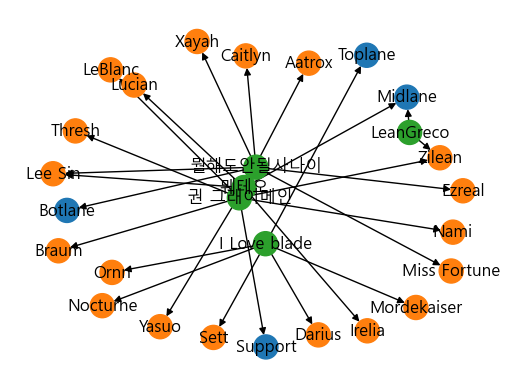

In [4]:
nodes_types = nx.get_node_attributes(g, 'type')
nodes_player = [node for node in nodes_types if nodes_types[node] == "Player"]
nodes_champion = [node for node in nodes_types if nodes_types[node] == "Champion"]
nodes_position = [node for node in nodes_types if nodes_types[node] == "Position"]

subgraph = nx.DiGraph(g.subgraph(nodes_champion + nodes_position + nodes_player[:5]))
subgraph.remove_nodes_from([node for node, degree in dict(subgraph.degree()).items() if degree == 0])
visualize_graph(subgraph)

## Train-/ Test-Splits

In order to generate the train and test set we build a dataframe from the positions of the players. 
Then we create a train and test set with a (90%, 10%) split. 
To avoid data leakage, we remove the test-set edges from the graph. 

In [5]:
edges = nx.to_pandas_edgelist(g)
edges = edges[['source', 'type', 'target']]
edges_position = edges[edges["type"] == "HAS_POSITION"]
edges_champ = edges[edges["type"] == "PLAYS_CHAMP"]
print(edges)
edges_position_train, edges_position_test_validation = train_test_split(edges_position, random_state=random_state, train_size=0.8)
edges_position_test, edges_position_validation = train_test_split(edges_position_test_validation, random_state=random_state, train_size=0.5)

                                           source          type  \
0       4:abbe0952-2458-485b-a26a-9f3828f2c994:12  HAS_POSITION   
1       4:abbe0952-2458-485b-a26a-9f3828f2c994:12   PLAYS_CHAMP   
2       4:abbe0952-2458-485b-a26a-9f3828f2c994:12   PLAYS_CHAMP   
3       4:abbe0952-2458-485b-a26a-9f3828f2c994:12   PLAYS_CHAMP   
4       4:abbe0952-2458-485b-a26a-9f3828f2c994:12   PLAYS_CHAMP   
...                                           ...           ...   
1208  4:abbe0952-2458-485b-a26a-9f3828f2c994:4345   PLAYS_CHAMP   
1209  4:abbe0952-2458-485b-a26a-9f3828f2c994:4345   PLAYS_CHAMP   
1210  4:abbe0952-2458-485b-a26a-9f3828f2c994:4345   PLAYS_CHAMP   
1211  4:abbe0952-2458-485b-a26a-9f3828f2c994:4350  HAS_POSITION   
1212  4:abbe0952-2458-485b-a26a-9f3828f2c994:4350   PLAYS_CHAMP   

                                              target  
0     4:abbe0952-2458-485b-a26a-9f3828f2c994:1833124  
1      4:abbe0952-2458-485b-a26a-9f3828f2c994:234855  
2      4:abbe0952-2458-485b-a2

In [6]:
training  = TriplesFactory.from_labeled_triples(triples=pd.concat([edges_champ, edges_position_train]).values)
training 

TriplesFactory(num_entities=351, num_relations=2, create_inverse_triples=False, num_triples=1170)

In [7]:
validation = TriplesFactory.from_labeled_triples(triples=edges_position_validation.values)
validation 

TriplesFactory(num_entities=27, num_relations=1, create_inverse_triples=False, num_triples=22)

In [8]:
testing = TriplesFactory.from_labeled_triples(triples=edges_position_test.values)
testing 

TriplesFactory(num_entities=26, num_relations=1, create_inverse_triples=False, num_triples=21)

In [9]:
result = pipeline(
    model="transr",
    training=training,
    validation=validation,
    testing=validation,
    random_seed=random_state,
    model_kwargs=dict(embedding_dim=20), #scoring_fct_norm=1
    training_kwargs=dict(num_epochs=50, batch_size=128),
    optimizer_kwargs=dict(lr=0.01),
    device="cuda",
    #stopper="early",
    #stopper_kwargs=dict(frequency=1, relative_delta=0.002),
)

Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/10 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/22.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.22s seconds


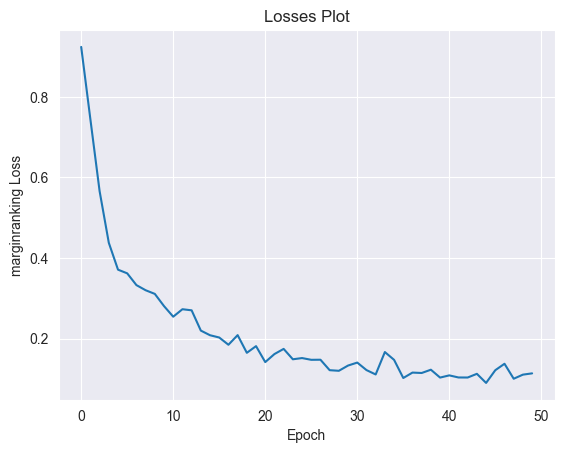

In [10]:
result.plot_losses()
plt.savefig("../img/Losses_PyKEEN_TransE.png")
plt.show()

In [11]:
def predict(model):
    y, y_hat = [], []
    
    for row in tqdm.tqdm(edges_position_train.itertuples()):
        source, target = row[1], row[3]
    
        pred = predict_target(model=model, head=source, relation="HAS_POSITION", triples_factory=training)
        pred_df = pred.df.loc[pred.df[pred.df["tail_label"].isin(nodes_position)]["score"].idxmax()]
        
        target = g.nodes[target]["properties"]["positionID"]
        pred = g.nodes[pred_df["tail_label"]]["properties"]["positionID"]
        
        y.append(target)
        y_hat.append(pred)
        
    return y, y_hat

test_targets, test_predictions = predict(result.model)

170it [00:00, 485.00it/s]


In [12]:
print(classification_report(test_targets, test_predictions))

              precision    recall  f1-score   support

         BOT       1.00      0.80      0.89        20
         JGL       0.67      1.00      0.80        24
         MID       0.91      0.91      0.91        32
         SUP       1.00      0.89      0.94        66
         TOP       0.96      0.93      0.95        28

    accuracy                           0.91       170
   macro avg       0.91      0.91      0.90       170
weighted avg       0.93      0.91      0.91       170

